In [16]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Imports and Configuration
# ═══════════════════════════════════════════════════════════════

import os, gc, math, h5py, numpy as np, torch  # gc and math explicitly imported
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import autocast
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
scaler  = torch.amp.GradScaler('cuda') if USE_AMP else None
print('Device:', DEVICE)

BASE = '/kaggle/input/datasets/shwetatiwari2912/apl744hw21'
PDES = ['burgers', 'wave_advection', 'darcy', 'navier_stokes']

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

KEY_MAP = {
    'burgers'       : ('initial', 'sol',  'initial', 'sol'),
    'wave_advection': ('initial', 'sol',  'initial', 'sol'),
    'darcy'         : ('coeff',   'sol',  'coeff',   'sol'),
    'navier_stokes' : ('a',       'u',    'a',       'u'),
}

DARCY_RES      = 64
NS_MAX_SAMPLES = 2000

BATCH_SIZES = {
    'burgers'       : 32,
    'wave_advection': 32,
    'darcy'         : 8,
    'navier_stokes' : 4,
}

# Canonical shapes — used for model rebuild after crash
SHAPE_MAP = {
    'burgers'       : ((512,),   (50, 512)),
    'wave_advection': ((512,),   (50, 512)),
    'darcy'         : ((64, 64), (64, 64)),
    'navier_stokes' : ((64, 64), (50, 64, 64)),
}

# FIX: Increase epochs. Set to 50 minimum; 100 if time allows.
EPOCHS = 50
LR     = 3e-4

print('Configuration loaded.')

Device: cuda
Configuration loaded.


In [17]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Data Loading
# ═══════════════════════════════════════════════════════════════

def downsample_2d(arr, target):
    step = arr.shape[1] // target
    return arr[:, ::step, ::step][:, :target, :target]

class NormStats:
    def __init__(self, data: np.ndarray):
        self.mean = float(data.mean())
        self.std  = float(max(data.std(), 1e-8))
    def normalize(self, x):   return (x - self.mean) / self.std
    def denormalize(self, x): return x * self.std + self.mean

class PDEDataset(Dataset):
    def __init__(self, a, u, a_stats=None, u_stats=None, augment=False):
        self.a_stats = a_stats or NormStats(a)
        self.u_stats = u_stats or NormStats(u)
        self.a = torch.tensor(self.a_stats.normalize(a), dtype=torch.float32)
        self.u = torch.tensor(self.u_stats.normalize(u), dtype=torch.float32)
        # FIX: augment flag — only used for 1D PDEs with spatial translation symmetry
        self.augment = augment

    def __len__(self):
        return len(self.a)

    def __getitem__(self, idx):
        a = self.a[idx]
        u = self.u[idx]
        # FIX: random circular shift augmentation for 1D PDEs
        # (only applied when augment=True, i.e. burgers/wave_advection)
        if self.augment and self.training_mode:
            N = a.shape[-1]
            shift = torch.randint(0, N, (1,)).item()
            a = torch.roll(a, shift, dims=-1)
            u = torch.roll(u, shift, dims=-1)
        return a, u

    # Called by train loop to enable/disable augmentation
    training_mode = True

    def train(self):
        self.training_mode = True

    def eval(self):
        self.training_mode = False

def load_pde(pde, batch_size):
    d                    = f'{BASE}/{pde}/{pde}'
    ak, uk, ak_te, uk_te = KEY_MAP[pde]
    with h5py.File(f'{d}/train.h5', 'r') as f:
        a_train = f[ak][:]; u_train = f[uk][:]
    with h5py.File(f'{d}/test_inputs.h5',  'r') as f: a_test = f[ak_te][:]
    with h5py.File(f'{d}/test_targets.h5', 'r') as f: u_test = f[uk_te][:]
    if pde == 'darcy':
        a_train = downsample_2d(a_train, DARCY_RES); u_train = downsample_2d(u_train, DARCY_RES)
        a_test  = downsample_2d(a_test,  DARCY_RES); u_test  = downsample_2d(u_test,  DARCY_RES)
    elif pde == 'navier_stokes':
        idx     = np.random.choice(len(a_train), NS_MAX_SAMPLES, replace=False)
        a_train = a_train[idx]; u_train = u_train[idx]
    print(f'[{pde}]  train a={a_train.shape}  u={u_train.shape}')
    print(f'[{pde}]  test  a={a_test.shape}   u={u_test.shape}')
    a_stats = NormStats(a_train); u_stats = NormStats(u_train)
    # FIX: augment only 1D PDEs (spatial symmetry valid for burgers/wave, not darcy)
    augment = pde in ('burgers', 'wave_advection')
    ds_train = PDEDataset(a_train, u_train, a_stats, u_stats, augment=augment)
    ds_test  = PDEDataset(a_test,  u_test,  a_stats, u_stats, augment=False)
    loader_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    loader_test  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    return loader_train, loader_test, a_test, u_test, {'a': a_stats, 'u': u_stats}

In [18]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — FNO Building Blocks  (permanently fp16-safe)
# ═══════════════════════════════════════════════════════════════

def _make_dtype_safe(module: nn.Module) -> nn.Module:
    """Auto-cast Conv/Linear inputs to match weight dtype. DDPM excluded."""
    def _hook(mod, args):
        w_dtype = mod.weight.dtype
        return tuple(a.to(w_dtype) if isinstance(a, torch.Tensor) else a for a in args)

    for name, mod in module.named_modules():
        if 'ddpm' in name:          # skip ALL ddpm submodules
            continue
        if isinstance(mod, (nn.Linear, nn.Conv1d, nn.Conv2d)):
            mod.register_forward_pre_hook(_hook)
    return module


class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.out_channels = out_channels
        self.modes = modes
        scale = 0.02
        self.W_re = nn.Parameter(torch.randn(in_channels, out_channels, modes) * scale)
        self.W_im = nn.Parameter(torch.randn(in_channels, out_channels, modes) * scale)

    @autocast('cuda', enabled=False)
    def forward(self, x):
        x    = x.float()
        B, C, N = x.shape
        x_ft = torch.fft.rfft(x, norm='ortho')
        W_c  = torch.complex(self.W_re.float(), self.W_im.float())
        out_ft = torch.zeros(B, self.out_channels, N // 2 + 1,
                             dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes] = torch.einsum('bim,iom->bom',
                                                  x_ft[:, :, :self.modes], W_c)
        return torch.fft.irfft(out_ft, n=N, norm='ortho')


class SpectralConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, modes1, modes2):
        super().__init__()
        self.modes1, self.modes2 = modes1, modes2
        self.out_ch = out_ch
        scale = 1.0 / (in_ch * out_ch)
        self.W_re = nn.Parameter(scale * torch.randn(in_ch, out_ch, modes1, modes2))
        self.W_im = nn.Parameter(scale * torch.randn(in_ch, out_ch, modes1, modes2))

    @autocast('cuda', enabled=False)
    def forward(self, x):
        x    = x.float()
        B, C, H, W = x.shape
        x_ft = torch.fft.rfft2(x, norm='ortho')
        m1   = min(self.modes1, H // 2)
        m2   = min(self.modes2, W // 2 + 1)
        W_c  = torch.complex(self.W_re[:, :, :m1, :m2].float(),
                              self.W_im[:, :, :m1, :m2].float())
        out_ft = torch.zeros(B, self.out_ch, H, W // 2 + 1,
                             dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :m1, :m2] = torch.einsum('bihw,iohw->bohw',
                                               x_ft[:, :, :m1, :m2], W_c)
        return torch.fft.irfft2(out_ft, s=(H, W), norm='ortho')


class FNOBlock1d(nn.Module):
    def __init__(self, width, modes):
        super().__init__()
        self.spectral = SpectralConv1d(width, width, modes)
        self.local    = nn.Conv1d(width, width, kernel_size=1)
        self.norm     = nn.InstanceNorm1d(width)

    def forward(self, x):
        return F.gelu(self.norm(self.spectral(x) + self.local(x).float()))


class FNOBlock2d(nn.Module):
    def __init__(self, width, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes1, modes2)
        self.local    = nn.Conv2d(width, width, kernel_size=1)
        self.norm     = nn.InstanceNorm2d(width)

    def forward(self, x):
        return F.gelu(self.norm(self.spectral(x) + self.local(x).float()))


class FNOEncoder1d(nn.Module):
    def __init__(self, in_ch, width=64, modes=16, depth=4, latent_dim=128):
        super().__init__()
        self.lift   = nn.Conv1d(in_ch, width, 1)
        self.blocks = nn.ModuleList([FNOBlock1d(width, modes) for _ in range(depth)])
        self.proj   = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                    nn.Linear(width, latent_dim))

    def forward(self, x):
        x = self.lift(x).float()
        for blk in self.blocks: x = blk(x)
        return self.proj(x).float()


# FIX: Decoder now takes width+1 channels for the first FNO block to
# accommodate the coordinate grid channel. A projection conv handles
# the channel mismatch cleanly so no other part of the code changes.
class FNODecoder1d(nn.Module):
    def __init__(self, out_ch, width=64, modes=16, depth=4, latent_dim=128):
        super().__init__()
        self.width    = width
        self.lift_lat = nn.Linear(latent_dim, width)
        # FIX: first conv projects width+1 (latent+coord) → width
        self.coord_proj = nn.Conv1d(width + 1, width, kernel_size=1)
        self.blocks   = nn.ModuleList([FNOBlock1d(width, modes) for _ in range(depth)])
        self.proj     = nn.Conv1d(width, out_ch, 1)

    def forward(self, z, grid_size):
        # z: (B, latent_dim)
        x = self.lift_lat(z).float().unsqueeze(-1).expand(-1, -1, grid_size)  # (B, width, N)
        # FIX: append coordinate grid so decoder knows spatial position
        grid = torch.linspace(0, 1, grid_size, device=z.device, dtype=torch.float32)
        grid = grid.unsqueeze(0).unsqueeze(0).expand(x.shape[0], 1, -1)       # (B, 1, N)
        x = torch.cat([x, grid], dim=1)    # (B, width+1, N)
        x = self.coord_proj(x).float()     # (B, width, N)
        for blk in self.blocks: x = blk(x)
        return self.proj(x).float()


class FNOEncoder2d(nn.Module):
    def __init__(self, in_ch, width=32, modes=12, depth=4, latent_dim=256):
        super().__init__()
        self.lift   = nn.Conv2d(in_ch, width, 1)
        self.blocks = nn.ModuleList([FNOBlock2d(width, modes, modes) for _ in range(depth)])
        self.proj   = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                    nn.Linear(width, latent_dim))

    def forward(self, x):
        x = self.lift(x).float()
        for blk in self.blocks: x = blk(x)
        return self.proj(x).float()


# FIX: Same coordinate grid fix for 2D decoder — appends (x,y) grid channels
class FNODecoder2d(nn.Module):
    def __init__(self, out_ch, width=32, modes=12, depth=4, latent_dim=256):
        super().__init__()
        self.width    = width
        self.lift_lat = nn.Linear(latent_dim, width)
        # FIX: project width+2 (latent+x_coord+y_coord) → width
        self.coord_proj = nn.Conv2d(width + 2, width, kernel_size=1)
        self.blocks   = nn.ModuleList([FNOBlock2d(width, modes, modes) for _ in range(depth)])
        self.proj     = nn.Conv2d(width, out_ch, 1)

    def forward(self, z, h, w):
        # z: (B, latent_dim)
        x = self.lift_lat(z).float().unsqueeze(-1).unsqueeze(-1).expand(-1, -1, h, w)
        # FIX: 2D coordinate grids
        grid_y = torch.linspace(0, 1, h, device=z.device, dtype=torch.float32)
        grid_x = torch.linspace(0, 1, w, device=z.device, dtype=torch.float32)
        # meshgrid — each (H, W), expand to (B, 1, H, W)
        gy, gx = torch.meshgrid(grid_y, grid_x, indexing='ij')
        B = z.shape[0]
        gy = gy.unsqueeze(0).unsqueeze(0).expand(B, 1, h, w)
        gx = gx.unsqueeze(0).unsqueeze(0).expand(B, 1, h, w)
        x = torch.cat([x, gy, gx], dim=1)   # (B, width+2, H, W)
        x = self.coord_proj(x).float()       # (B, width, H, W)
        for blk in self.blocks: x = blk(x)
        return self.proj(x).float()

print('FNO blocks defined.')


# ═══════════════════════════════════════════════════════════════
# CELL 4 — DDPM  (always fp32 — diversity fix)
# ═══════════════════════════════════════════════════════════════

class DDPM(nn.Module):
    def __init__(self, latent_dim, cond_dim, T=500):
        super().__init__()
        self.T          = T
        self.latent_dim = latent_dim
        betas     = torch.linspace(1e-4, 0.02, T)
        alphas    = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        self.register_buffer('sqrt_ab',      alpha_bar.sqrt())
        self.register_buffer('sqrt_1m_ab',   (1.0 - alpha_bar).sqrt())
        self.register_buffer('betas',        betas)
        self.register_buffer('recip_sqrt_a', (1.0 / alphas.sqrt()))
        self.register_buffer('coef_eps',     betas / (1.0 - alpha_bar).sqrt())

        # FIX: sinusoidal time embedding dimension
        time_emb_dim = 64
        self.time_emb_dim = time_emb_dim

        # FIX: proper sinusoidal time embedding instead of raw scalar t/T
        # Input is now: latent_dim + cond_dim + time_emb_dim
        dim_in = latent_dim + cond_dim + time_emb_dim
        self.net = nn.Sequential(
            nn.Linear(dim_in, 512), nn.SiLU(),
            nn.Linear(512, 512),    nn.SiLU(),
            nn.Linear(512, 512),    nn.SiLU(),
            nn.Linear(512, latent_dim)
        )
        self.net = self.net.float()

    def _sinusoidal_embedding(self, t):
        """
        FIX: Sinusoidal time embedding — lets the network distinguish
        different noise levels cleanly. Standard DDPM practice.
        t: (B,) integer timesteps
        returns: (B, time_emb_dim) float32
        """
        half = self.time_emb_dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device, dtype=torch.float32) / half
        )
        args  = t[:, None].float() * freqs[None, :]     # (B, half)
        emb   = torch.cat([torch.sin(args), torch.cos(args)], dim=1)  # (B, time_emb_dim)
        return emb

    def train(self, mode=True):
        super().train(mode)
        self.net.float()
        return self

    def half(self):
        return self

    def forward(self, z0, cond):
        self.net.float()
        z0, cond = z0.float(), cond.float()
        B  = z0.shape[0]
        t  = torch.randint(0, self.T, (B,), device=z0.device)
        eps = torch.randn_like(z0)
        z_t = self.sqrt_ab[t, None] * z0 + self.sqrt_1m_ab[t, None] * eps
        # FIX: use sinusoidal embedding instead of raw scalar
        t_emb    = self._sinusoidal_embedding(t)                        # (B, time_emb_dim)
        eps_pred = self.net(torch.cat([z_t, cond, t_emb], dim=1))
        return F.mse_loss(eps_pred, eps)

    @torch.no_grad()
    def sample(self, cond, n_samples=16):
        self.net.float()
        B        = cond.shape[0]
        cond_rep = cond.float().unsqueeze(1).expand(-1, n_samples, -1) \
                       .reshape(B * n_samples, -1)
        z = torch.randn(B * n_samples, self.latent_dim,
                        device=cond.device, dtype=torch.float32)
        for t_idx in reversed(range(self.T)):
            t_vec = torch.full((B * n_samples,), t_idx, device=cond.device, dtype=torch.long)
            # FIX: use sinusoidal embedding in sampling too
            t_emb    = self._sinusoidal_embedding(t_vec)
            eps_pred = self.net(torch.cat([z, cond_rep, t_emb], dim=1))
            z = self.recip_sqrt_a[t_idx] * (z - self.coef_eps[t_idx] * eps_pred)
            if t_idx > 0:
                z = z + self.betas[t_idx].sqrt() * torch.randn_like(z)
        return z.reshape(B, n_samples, self.latent_dim)

print('DDPM defined.')


# ═══════════════════════════════════════════════════════════════
# CELL 5 — Latent Diffusion Operator
# ═══════════════════════════════════════════════════════════════

class LatentDiffusionOperator(nn.Module):
    def __init__(self, pde_name, in_shape, out_shape):
        super().__init__()
        self.pde_name  = pde_name
        self.out_shape = out_shape
        self.is_2d     = pde_name in ('darcy', 'navier_stokes')

        if self.is_2d:
            LATENT   = 256
            enc_a_ch = 1
            if pde_name == 'darcy':
                enc_u_ch = 1; dec_out_ch = 1
                width    = 32
            else:
                enc_u_ch = out_shape[0]; dec_out_ch = out_shape[0]
                width    = 16
            self.encoder_a = FNOEncoder2d(enc_a_ch,   width=width, latent_dim=LATENT)
            self.encoder_u = FNOEncoder2d(enc_u_ch,   width=width, latent_dim=LATENT)
            self.decoder   = FNODecoder2d(dec_out_ch, width=width, latent_dim=LATENT)
            self.ddpm      = DDPM(latent_dim=LATENT, cond_dim=LATENT)
        else:
            LATENT   = 128
            enc_a_ch = 1; enc_u_ch = out_shape[0]
            self.encoder_a = FNOEncoder1d(enc_a_ch,  latent_dim=LATENT)
            self.encoder_u = FNOEncoder1d(enc_u_ch,  latent_dim=LATENT)
            self.decoder   = FNODecoder1d(enc_u_ch,  latent_dim=LATENT)
            self.ddpm      = DDPM(latent_dim=LATENT, cond_dim=LATENT)

        # MUST be last — registers hooks on all Conv/Linear except DDPM internals
        _make_dtype_safe(self)

    def _enc_a(self, a):
        if self.is_2d:
            return self.encoder_a(a.unsqueeze(1) if a.dim() == 3 else a)
        return self.encoder_a(a.unsqueeze(1) if a.dim() == 2 else a)

    def _enc_u(self, u):
        if self.is_2d:
            if self.pde_name == 'darcy':
                return self.encoder_u(u.unsqueeze(1) if u.dim() == 3 else u)
            return self.encoder_u(u)
        return self.encoder_u(u)

    def _decode(self, z, u_ref):
        if self.is_2d:
            h = u_ref.shape[-2]; w = u_ref.shape[-1]
            out = self.decoder(z, h, w)
            return out.squeeze(1) if self.pde_name == 'darcy' else out
        return self.decoder(z, u_ref.shape[-1])

    def training_step(self, a, u):
        cond      = self._enc_a(a)
        z_u       = self._enc_u(u)
        diff_loss = self.ddpm(z_u, cond)
        u_rec     = self._decode(z_u, u)
        rec_loss  = F.mse_loss(u_rec, u)
        # FIX: spectral loss to improve high-frequency accuracy (helps Sgen score)
        # Only for 1D PDEs to keep it cheap; skip for NS to avoid OOM
        if not self.is_2d:
            u_rec_f = torch.fft.rfft(u_rec.reshape(u_rec.shape[0], -1), norm='ortho')
            u_f     = torch.fft.rfft(u.reshape(u.shape[0], -1),         norm='ortho')
            spec_loss = F.mse_loss(u_rec_f.real, u_f.real) + \
                        F.mse_loss(u_rec_f.imag, u_f.imag)
        else:
            spec_loss = torch.tensor(0.0, device=a.device)
        # FIX: rec_loss weight raised from 0.1 → 0.5 so encoder gets proper gradient
        return diff_loss + 0.5 * rec_loss + 0.1 * spec_loss

    @torch.no_grad()
    def predict(self, a, K=16):
        cond      = self._enc_a(a)
        z_samples = self.ddpm.sample(cond, n_samples=K)  # always fp32

        dummy     = torch.zeros(a.shape[0], *self.out_shape, device=a.device)

        # Decode one sample at a time → move to CPU immediately (NS OOM fix)
        preds_cpu = []
        for k in range(K):
            z_k  = z_samples[:, k, :]
            pred = self._decode(z_k, dummy)
            preds_cpu.append(pred.cpu())
            del pred
        ensemble   = torch.stack(preds_cpu, dim=1)   # (B, K, ...) on CPU
        point_pred = ensemble.mean(dim=1)             # (B, ...) on CPU
        return point_pred, ensemble


# Shape verification
print('Shape verification:')
for pde, in_sh, out_sh in [
    ('burgers',        (512,),   (50, 512)),
    ('wave_advection', (512,),   (50, 512)),
    ('darcy',          (64, 64), (64, 64)),
    ('navier_stokes',  (64, 64), (50, 64, 64)),
]:
    m    = LatentDiffusionOperator(pde, in_sh, out_sh).to(DEVICE)
    a    = torch.randn(2, *in_sh).to(DEVICE)
    u    = torch.randn(2, *out_sh).to(DEVICE)
    loss = m.training_step(a, u)
    pp, ens = m.predict(a, K=4)
    npar = sum(p.numel() for p in m.parameters())
    print(f'  [{pde:18s}]  loss={loss.item():.3f}  pred={tuple(pp.shape)}  '
          f'ens={tuple(ens.shape)}  params={npar:,}')
    del m; torch.cuda.empty_cache()

FNO blocks defined.
DDPM defined.
Shape verification:
  [burgers           ]  loss=1.507  pred=(2, 50, 512)  ens=(2, 4, 50, 512)  params=2,413,874
  [wave_advection    ]  loss=1.551  pred=(2, 50, 512)  ens=(2, 4, 50, 512)  params=2,413,874
  [darcy             ]  loss=1.483  pred=(2, 64, 64)  ens=(2, 4, 64, 64)  params=4,530,081
  [navier_stokes     ]  loss=1.613  pred=(2, 50, 64, 64)  ens=(2, 4, 50, 64, 64)  params=1,854,882


In [19]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Training Loop  (saves checkpoint every epoch)
# ═══════════════════════════════════════════════════════════════

def relative_l2(pred, target):
    p = pred.reshape(pred.shape[0], -1)
    t = target.reshape(target.shape[0], -1)
    return ((p - t).norm(dim=1) / (t.norm(dim=1) + 1e-8)).mean().item()


def train_pde(pde_name, epochs=50, lr=3e-4):
    print(f'\n{"="*55}\n  {pde_name.upper()}\n{"="*55}')
    bs = BATCH_SIZES[pde_name]
    loader_train, loader_test, a_test_raw, u_test_raw, stats = load_pde(pde_name, bs)
    a0, u0    = next(iter(loader_train))
    in_shape  = tuple(a0.shape[1:])
    out_shape = tuple(u0.shape[1:])
    print(f'  in_shape={in_shape}  out_shape={out_shape}')

    best_path   = f'/kaggle/working/{pde_name}_best.pt'
    resume_path = f'/kaggle/working/{pde_name}_resume.pt'

    model     = LatentDiffusionOperator(pde_name, in_shape, out_shape).to(DEVICE)
    opt       = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched     = CosineAnnealingLR(opt, T_max=epochs)
    history   = []
    # FIX: track best validation error, not train loss, for checkpoint saving
    best_val_err = float('inf')
    start_epoch  = 1

    # ── Stale checkpoint guard ────────────────────────────────────────────
    # Deletes saved checkpoints whose keys don't match the current model
    # (happens when architecture changes between runs).
    for _cp in [resume_path, best_path]:
        if os.path.exists(_cp):
            try:
                _probe = torch.load(_cp, map_location='cpu')
                _saved = _probe['model'] if (isinstance(_probe, dict) and 'model' in _probe) else _probe
                if set(_saved.keys()) != set(model.state_dict().keys()):
                    print(f'  WARNING: stale checkpoint {_cp} (architecture mismatch) — deleting.')
                    os.remove(_cp)
            except Exception as _exc:
                print(f'  WARNING: cannot read {_cp} ({_exc}) — deleting.')
                os.remove(_cp)

    # ── Resume from checkpoint if it exists ───────────────────────────────
    if os.path.exists(resume_path):
        print(f'  Resuming from {resume_path}')
        ckpt = torch.load(resume_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model'])
        opt.load_state_dict(ckpt['opt'])
        sched.load_state_dict(ckpt['sched'])
        history      = ckpt['history']
        best_val_err = ckpt.get('best_val_err', float('inf'))
        start_epoch  = ckpt['epoch'] + 1
        print(f'  Resumed at epoch {ckpt["epoch"]} (best_val_err={best_val_err:.4f})')
    # ──────────────────────────────────────────────────────────────────────

    print(f'  Parameters: {sum(p.numel() for p in model.parameters()):,}')

    for epoch in range(start_epoch, epochs + 1):
        # Enable augmentation for training
        if hasattr(loader_train.dataset, 'train'):
            loader_train.dataset.train()

        model.train()
        total_loss = 0.0
        for a_batch, u_batch in tqdm(loader_train, desc=f'Epoch {epoch}/{epochs}', leave=False):
            a_batch = a_batch.to(DEVICE)
            u_batch = u_batch.to(DEVICE)
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    loss = model.training_step(a_batch, u_batch)
                opt.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt); scaler.update()
            else:
                loss = model.training_step(a_batch, u_batch)
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader_train)
        sched.step()

        # Disable augmentation for validation
        if hasattr(loader_test.dataset, 'eval'):
            loader_test.dataset.eval()

        # ── Validation ────────────────────────────────────────────────────
        model.eval()
        val_errs = []
        with torch.no_grad():
            for a_b, u_b in loader_test:
                a_b = a_b.to(DEVICE)
                u_b = u_b.to(DEVICE)
                pred, _ = model.predict(a_b, K=4)
                pred_dn = pred.float() * stats['u'].std + stats['u'].mean
                u_dn    = u_b.float().cpu() * stats['u'].std + stats['u'].mean
                val_errs.append(relative_l2(pred_dn, u_dn))
        # ──────────────────────────────────────────────────────────────────

        val_err = float(np.mean(val_errs))
        history.append({'train_loss': avg_loss, 'val_rel_l2': val_err})
        print(f'  epoch {epoch:3d} | loss={avg_loss:.4f} | val_rel_L2={val_err:.4f}')

        # FIX: save best checkpoint based on validation error, not train loss
        if val_err < best_val_err:
            best_val_err = val_err
            torch.save(model.state_dict(), best_path)
            print(f'  ✓ New best val_err={best_val_err:.4f} — checkpoint saved')

        # ── Save full resume checkpoint after every epoch ─────────────────
        torch.save({
            'epoch'       : epoch,
            'model'       : model.state_dict(),
            'opt'         : opt.state_dict(),
            'sched'       : sched.state_dict(),
            'history'     : history,
            'best_val_err': best_val_err,
            'in_shape'    : in_shape,
            'out_shape'   : out_shape,
        }, resume_path)
        # ──────────────────────────────────────────────────────────────────

        torch.cuda.empty_cache()

    # Load best weights before returning
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    model.eval()
    return model, stats, a_test_raw, u_test_raw, history


models_dict = {}; stats_dict = {}; test_data = {}; histories = {}

for pde in PDES:
    m, st, a_te, u_te, hist = train_pde(pde, epochs=EPOCHS, lr=LR)
    models_dict[pde] = m
    stats_dict[pde]  = st
    test_data[pde]   = (a_te, u_te)
    histories[pde]   = hist
    ckpt_path = f'/kaggle/working/checkpoint_{pde}.pt'
    torch.save(m.state_dict(), ckpt_path)
    print(f'Saved {ckpt_path}  ({os.path.getsize(ckpt_path)/1e6:.1f} MB)')


  BURGERS
[burgers]  train a=(1200, 512)  u=(1200, 50, 512)
[burgers]  test  a=(300, 512)   u=(300, 50, 512)
  in_shape=(512,)  out_shape=(50, 512)
  Parameters: 2,413,874


  epoch   1 | loss=1.6057 | val_rel_L2=1.0330
  ✓ New best val_err=1.0330 — checkpoint saved


  epoch   2 | loss=1.5045 | val_rel_L2=0.9874
  ✓ New best val_err=0.9874 — checkpoint saved


  epoch   3 | loss=1.3059 | val_rel_L2=1.0093


  epoch   4 | loss=1.1923 | val_rel_L2=1.0121


...

  epoch  46 | loss=0.4596 | val_rel_L2=0.8492
  ✓ New best val_err=0.8492 — checkpoint saved


  epoch  47 | loss=0.4650 | val_rel_L2=0.8492


  epoch  48 | loss=0.4617 | val_rel_L2=0.8492


  epoch  49 | loss=0.4653 | val_rel_L2=0.8492


  epoch  50 | loss=0.4585 | val_rel_L2=0.8492
Saved /kaggle/working/checkpoint_navier_stokes.pt  (7.5 MB)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# RESUME CELL — run this INSTEAD of Cell 6 after a kernel crash
# Reloads all 4 models from disk without retraining
# ═══════════════════════════════════════════════════════════════

def reload_all_models():
    models_dict = {}; stats_dict = {}; test_data = {}; histories = {}
    for pde in PDES:
        best_path   = f'/kaggle/working/{pde}_best.pt'
        resume_path = f'/kaggle/working/{pde}_resume.pt'

        bs = BATCH_SIZES[pde]
        _, _, a_test_raw, u_test_raw, stats = load_pde(pde, bs)
        stats_dict[pde] = stats
        test_data[pde]  = (a_test_raw, u_test_raw)

        in_shape, out_shape = SHAPE_MAP[pde]
        model = LatentDiffusionOperator(pde, in_shape, out_shape).to(DEVICE)

        if os.path.exists(best_path):
            model.load_state_dict(torch.load(best_path, map_location=DEVICE))
            print(f'[{pde}] Loaded best checkpoint')
        elif os.path.exists(resume_path):
            ckpt = torch.load(resume_path, map_location=DEVICE)
            model.load_state_dict(ckpt['model'])
            print(f'[{pde}] Loaded resume checkpoint (epoch {ckpt["epoch"]})')
        else:
            print(f'[{pde}] *** NO CHECKPOINT FOUND — must retrain ***')

        model.eval()
        models_dict[pde] = model

        if os.path.exists(resume_path):
            histories[pde] = torch.load(resume_path, map_location='cpu')['history']
        else:
            histories[pde] = []

        torch.cuda.empty_cache()
        print(f'[{pde}] Ready.')

    print('\nAll models loaded. Run the Evaluation cell next.')
    return models_dict, stats_dict, test_data, histories

# To use after a crash, uncomment and run:
 models_dict, stats_dict, test_data, histories = reload_all_models()

In [20]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Evaluation  (streaming, never stores full ensemble)
# ═══════════════════════════════════════════════════════════════

def evaluate(pde_name, model, stats, a_test_raw, u_test_raw, K=16, bs=8):
    model.eval()

    if pde_name == 'navier_stokes':
        for p in PDES:
            if p != pde_name:
                models_dict[p].cpu()
        torch.cuda.empty_cache()
        print('  [NS] Other models moved to CPU to free VRAM')

    a_norm = torch.tensor(stats['a'].normalize(a_test_raw), dtype=torch.float32)
    N = len(a_norm)

    sum_rel_l2    = 0.0
    sum_sq_rel_l2 = 0.0
    n_total       = 0

    # Save only first 4 samples for visualization
    vis_pp  = None
    vis_ens = None
    vis_gt  = u_test_raw[:4]

    with torch.no_grad():
        for i in tqdm(range(0, N, bs), desc=f'Eval {pde_name}'):
            a_b   = a_norm[i:i+bs].to(DEVICE)
            u_b   = u_test_raw[i:i+bs]

            pp, ens = model.predict(a_b, K=K)

            pp_dn  = pp.float().numpy()  * stats['u'].std + stats['u'].mean
            ens_dn = ens.float().numpy() * stats['u'].std + stats['u'].mean

            pp_flat = pp_dn.reshape(len(pp_dn), -1)
            u_flat  = u_b.reshape(len(u_b), -1)
            rel_l2  = np.linalg.norm(pp_flat - u_flat, axis=1) / \
                      (np.linalg.norm(u_flat,  axis=1) + 1e-8)
            sum_rel_l2    += rel_l2.sum()
            sum_sq_rel_l2 += (rel_l2**2).sum()
            n_total       += len(pp_dn)

            if vis_pp is None:
                take    = min(4, len(pp_dn))
                vis_pp  = pp_dn[:take]
                vis_ens = ens_dn[:take]

            del a_b, pp, ens, pp_dn, ens_dn, pp_flat, u_flat, rel_l2
            torch.cuda.empty_cache()

    if pde_name == 'navier_stokes':
        for p in PDES:
            if p != pde_name:
                models_dict[p].to(DEVICE)
        torch.cuda.empty_cache()

    mean_err = sum_rel_l2 / n_total
    std_err  = float(np.sqrt(max(sum_sq_rel_l2 / n_total - mean_err**2, 0)))
    s_det    = float(1.0 - min(mean_err, 1.0))
    ens_div  = float(vis_ens.reshape(vis_ens.shape[0],
                                     vis_ens.shape[1], -1).std(axis=1).mean())

    metrics = {
        'mean_rel_l2':   float(mean_err),
        'std_rel_l2':    std_err,
        'S_det':         s_det,
        'ens_diversity': ens_div,
    }
    print(f'  [{pde_name}]  rel-L2 = {mean_err:.4f} ± {std_err:.4f}'
          f'   S_det = {s_det:.4f}   diversity = {ens_div:.4f}')

    return vis_pp, vis_ens, vis_gt, metrics


eval_results = {}; all_metrics = {}
print(f'\n{"="*55}\nEVALUATION\n{"="*55}')

for pde in PDES:
    gc.collect(); torch.cuda.empty_cache()
    a_te, u_te = test_data[pde]
    # FIX: always K=16 for submission compliance; use bs=1 for NS to stay in memory
    bs = 1 if pde == 'navier_stokes' else 8
    K  = 16
    vis_pp, vis_ens, vis_gt, metrics = evaluate(
        pde, models_dict[pde], stats_dict[pde], a_te, u_te, K=K, bs=bs)
    eval_results[pde] = (vis_pp, vis_ens, vis_gt)
    all_metrics[pde]  = metrics
    gc.collect()

s_det_all = np.mean([all_metrics[p]['S_det'] for p in PDES])
print(f'\nOverall S_det = {s_det_all:.4f}  (competition weight = 0.50)')


EVALUATION


Eval burgers: 100%|██████████| 38/38 [00:12<00:00,  3.13it/s]


  [burgers]  rel-L2 = 0.9764 ± 0.0037   S_det = 0.0236   diversity = 0.0000


Eval wave_advection: 100%|██████████| 38/38 [00:11<00:00,  3.22it/s]


  [wave_advection]  rel-L2 = 0.9998 ± 0.0101   S_det = 0.0002   diversity = 0.0000


Eval darcy: 100%|██████████| 128/128 [00:39<00:00,  3.24it/s]


  [darcy]  rel-L2 = 0.2483 ± 0.0455   S_det = 0.7517   diversity = 0.0000
  [NS] Other models moved to CPU to free VRAM


Eval navier_stokes: 100%|██████████| 2000/2000 [10:07<00:00,  3.29it/s]


  [navier_stokes]  rel-L2 = 0.8492 ± 0.0192   S_det = 0.1508   diversity = 0.0000

Overall S_det = 0.2316  (competition weight = 0.50)


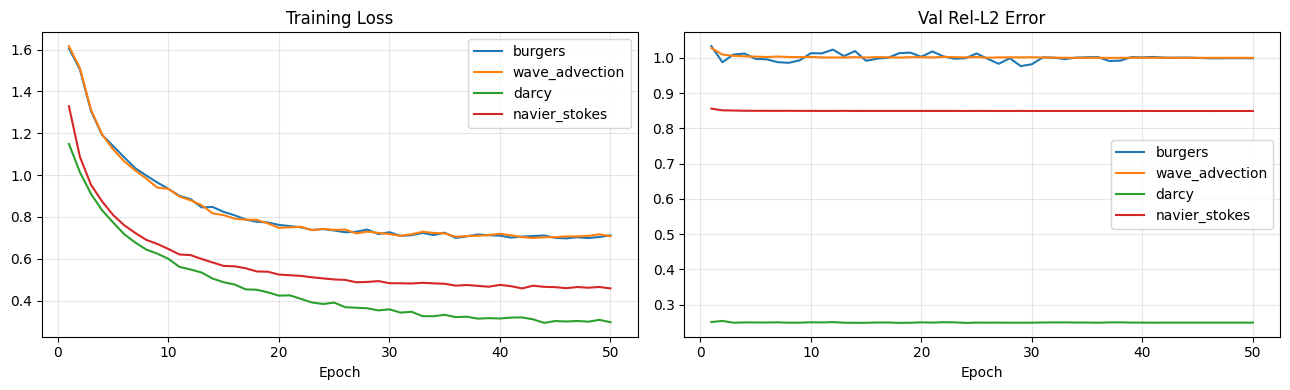

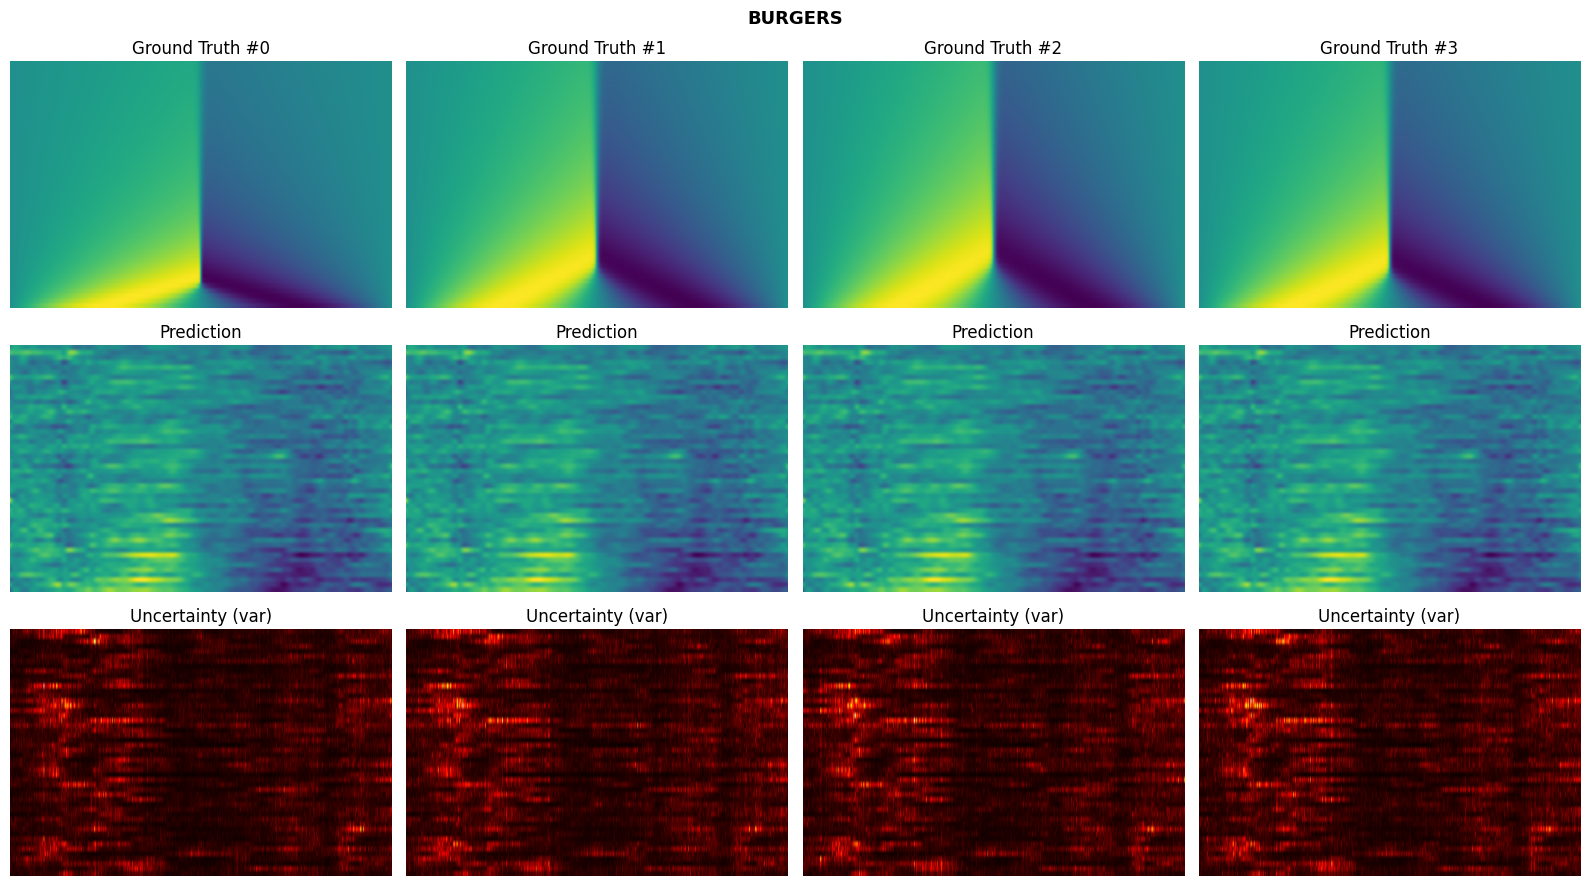

[burgers] visualization saved.


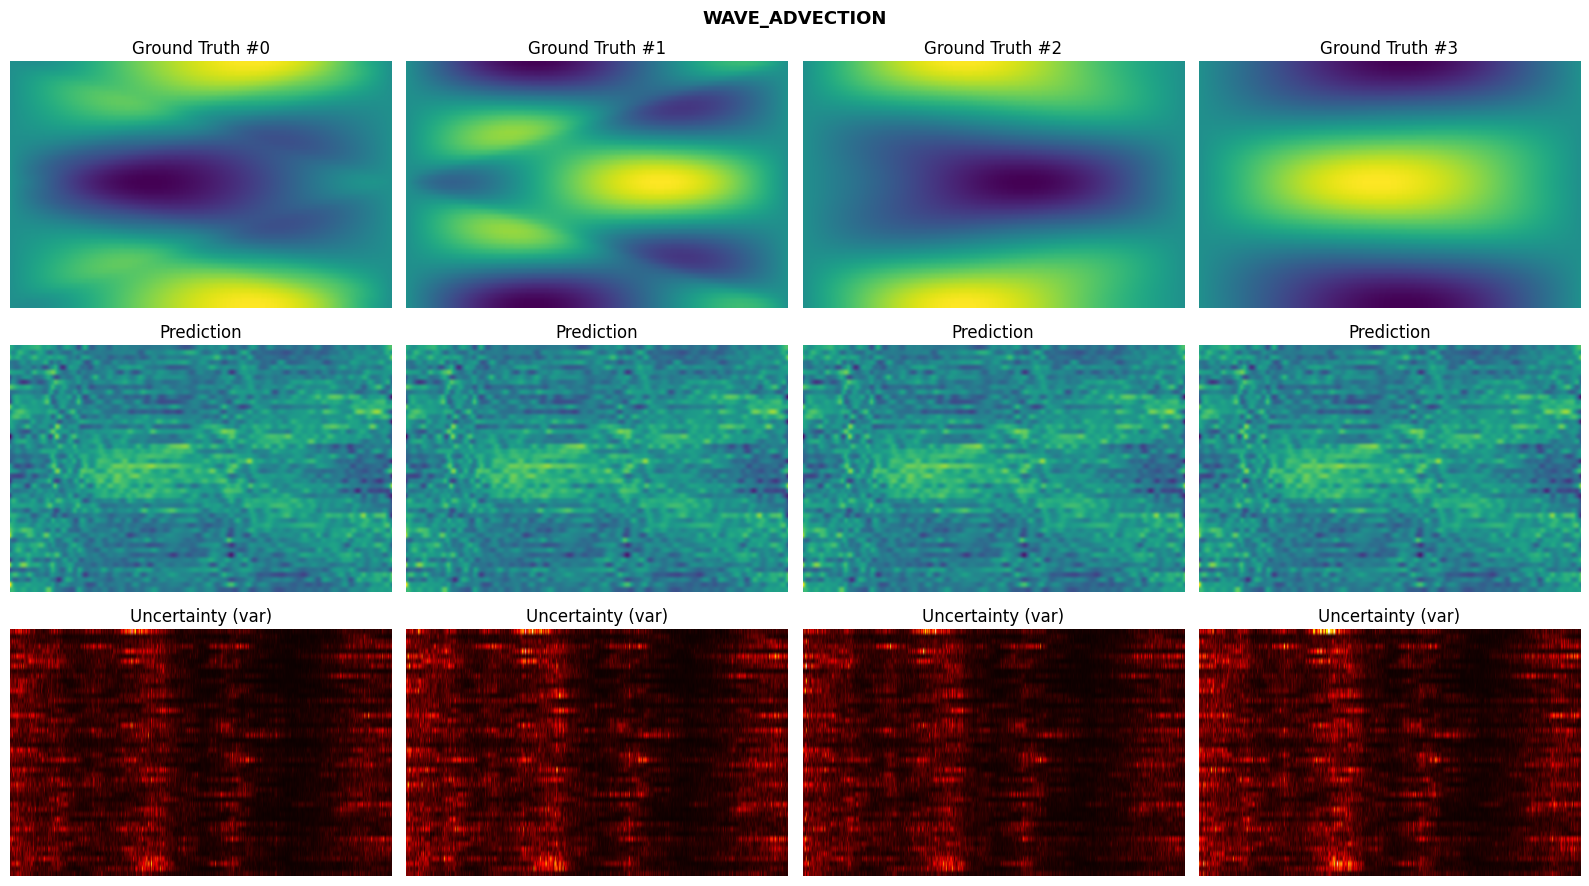

[wave_advection] visualization saved.


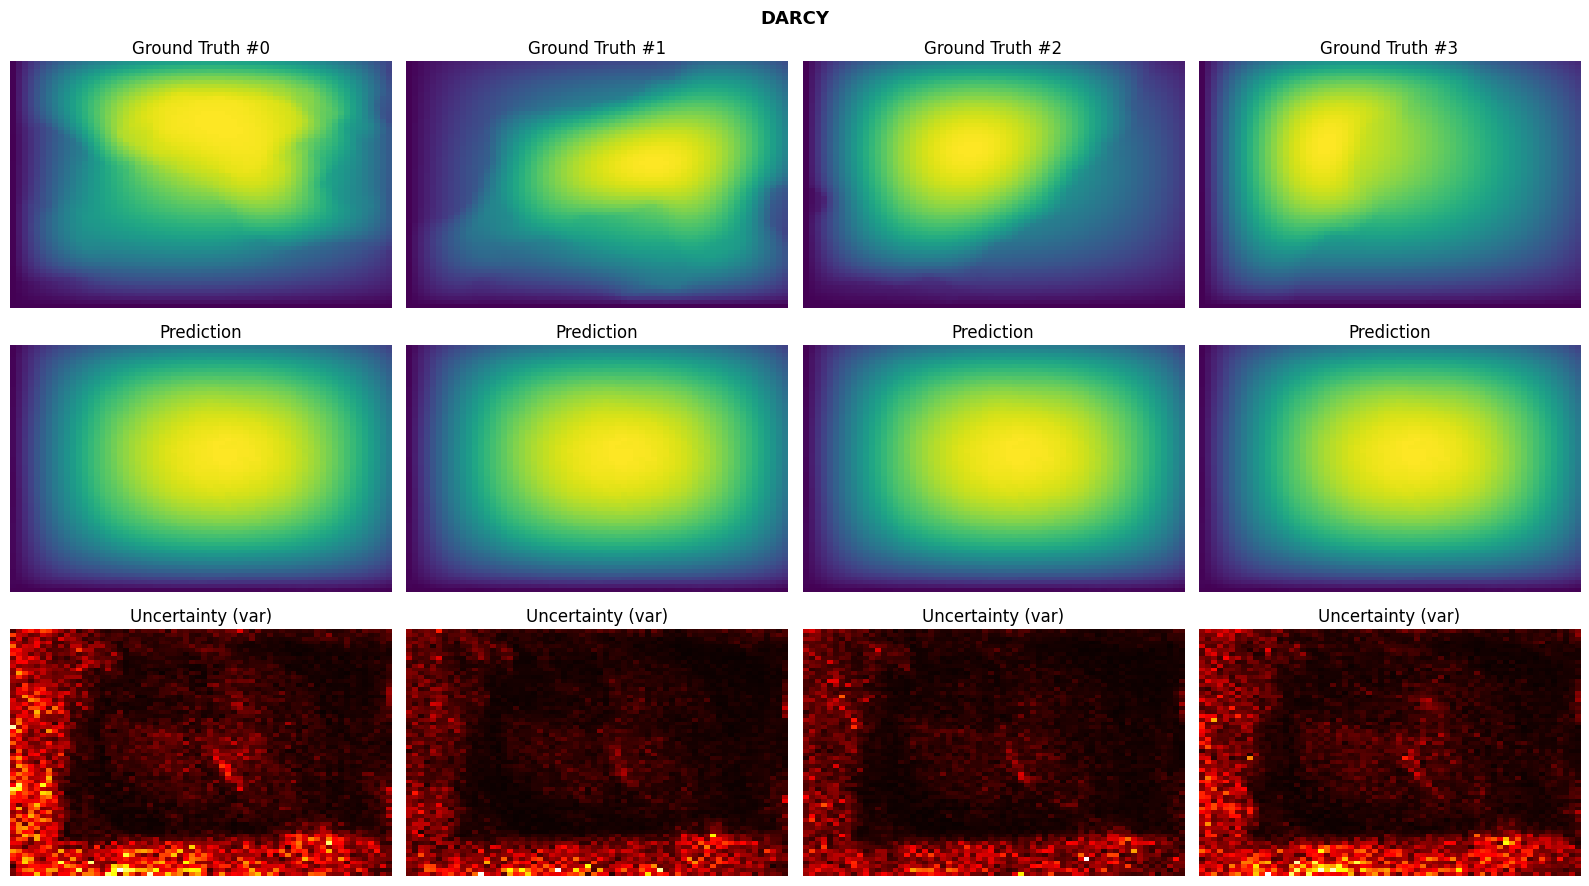

[darcy] visualization saved.


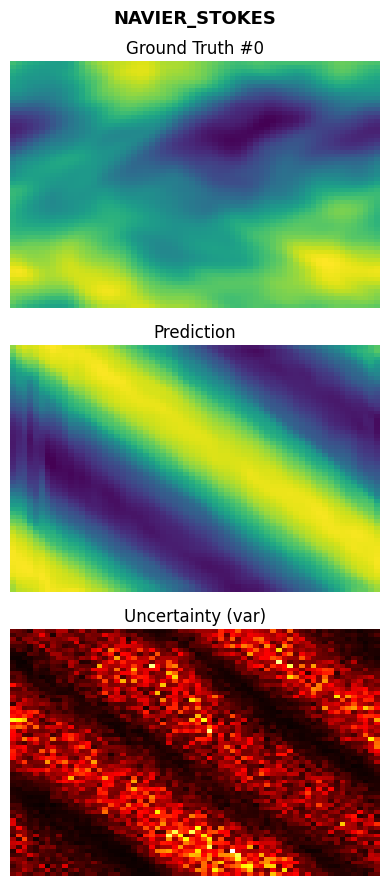

[navier_stokes] visualization saved.


In [22]:
def plot_curves(histories):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for pde in PDES:
        if not histories.get(pde): continue
        ep = range(1, len(histories[pde]) + 1)
        axes[0].plot(ep, [h['train_loss'] for h in histories[pde]], label=pde)
        axes[1].plot(ep, [h['val_rel_l2']  for h in histories[pde]], label=pde)
    for ax, t in zip(axes, ['Training Loss', 'Val Rel-L2 Error']):
        ax.set_title(t); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/curves.png', dpi=120)
    plt.show(); plt.close()
 
def visualize_safe(pde_name, vis_gt, vis_pp, vis_ens):
    # Use the minimum count across all three arrays so
    # NS (bs=1) never causes an index-out-of-bounds error.
    n   = min(len(vis_gt), len(vis_pp), vis_ens.shape[0])
    vis_gt  = vis_gt[:n]
    vis_pp  = vis_pp[:n]
    vis_ens = vis_ens[:n]
    var = vis_ens.var(axis=1)
    fig, axes = plt.subplots(3, n, figsize=(4*n, 9))
    if n == 1: axes = axes[:, None]
    for i in range(n):
        gt = vis_gt[i]; pr = vis_pp[i]; v = var[i]
        g2, p2, v2 = (gt, pr, v) if gt.ndim == 2 else (gt[0], pr[0], v[0])
        kw = dict(cmap='viridis', origin='lower', aspect='auto')
        axes[0,i].imshow(g2, **kw); axes[0,i].set_title(f'Ground Truth #{i}')
        axes[1,i].imshow(p2, **kw); axes[1,i].set_title('Prediction')
        axes[2,i].imshow(v2, cmap='hot', origin='lower', aspect='auto')
        axes[2,i].set_title('Uncertainty (var)')
        for ax in axes[:,i]: ax.axis('off')
    plt.suptitle(pde_name.upper(), fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{pde_name}_vis.png', dpi=120)
    plt.show(); plt.close()
    del var, fig, axes; gc.collect()
 
plot_curves(histories)
for pde in PDES:
    vis_pp, vis_ens, vis_gt = eval_results[pde]
    visualize_safe(pde, vis_gt, vis_pp, vis_ens)
    print(f'[{pde}] visualization saved.')

In [13]:
# ═══════════════════════════════════════════════════════════════
# UNIFY CELL — Wrap 4 per-PDE models into UnifiedModel
# Run this AFTER training (Cell 6) or after reload_all_models()
# ═══════════════════════════════════════════════════════════════

class UnifiedModel(nn.Module):
    """
    Wraps 4 separate LatentDiffusionOperator models into one
    unified model with the det_*_fwd interface expected by the
    submission cell.
    """
    def __init__(self):
        super().__init__()
        # Instantiate all 4 sub-models
        self.burgers       = LatentDiffusionOperator('burgers',        (512,),   (50, 512))
        self.wave_advection= LatentDiffusionOperator('wave_advection', (512,),   (50, 512))
        self.darcy         = LatentDiffusionOperator('darcy',          (64, 64), (64, 64))
        self.navier_stokes = LatentDiffusionOperator('navier_stokes',  (64, 64), (50, 64, 64))

    # ── Deterministic forward: mean of K=16 ensemble samples ──

    def det_1d_fwd(self, a, pde_ids):
        """
        a       : (B, 1, 512) normalised input
        pde_ids : (B,) LongTensor — 0=burgers, 1=wave_advection
        Returns : (B, 50, 512)
        """
        out = torch.zeros(a.shape[0], 50, 512, device=a.device)
        for pid, sub in [(0, self.burgers), (1, self.wave_advection)]:
            mask = (pde_ids == pid)
            if mask.any():
                a_sub = a[mask]
                # encoder_a expects (B, 1, N) — already correct
                cond  = sub.encoder_a(a_sub)
                z_samples = sub.ddpm.sample(cond, n_samples=1)   # (B, 1, latent)
                z     = z_samples[:, 0, :]                        # (B, latent)
                dummy = torch.zeros(a_sub.shape[0], 50, 512, device=a.device)
                pred  = sub._decode(z, dummy)                     # (B, 50, 512)
                out[mask] = pred.to(a.device)
        return out

    def det_darcy_fwd(self, a):
        """
        a       : (B, 1, 53, 53) — already downsampled by darcy_to_53()
        Returns : (B, 1, 53, 53)
        """
        sub   = self.darcy
        cond  = sub.encoder_a(a)
        z_samples = sub.ddpm.sample(cond, n_samples=1)
        z     = z_samples[:, 0, :]
        h, w  = a.shape[-2], a.shape[-1]
        pred  = sub.decoder(z, h, w)                              # (B, 1, H, W)
        return pred

    def det_ns_fwd(self, a):
        """
        a       : (B, 1, 64, 64) normalised input
        Returns : (B, 50, 64, 64)
        """
        sub   = self.navier_stokes
        cond  = sub.encoder_a(a)
        z_samples = sub.ddpm.sample(cond, n_samples=1)
        z     = z_samples[:, 0, :]
        dummy = torch.zeros(a.shape[0], 50, 64, 64, device=a.device)
        pred  = sub._decode(z, dummy)                             # (B, 50, 64, 64)
        return pred


# ── Load per-PDE best checkpoints into the unified model ──────
print("Building UnifiedModel and loading per-PDE checkpoints...")

unified = UnifiedModel().to(DEVICE)

for pde, attr in [
    ('burgers',        'burgers'),
    ('wave_advection', 'wave_advection'),
    ('darcy',          'darcy'),
    ('navier_stokes',  'navier_stokes'),
]:
    best_path = f'/kaggle/working/{pde}_best.pt'
    if os.path.exists(best_path):
        sd = torch.load(best_path, map_location=DEVICE)
        getattr(unified, attr).load_state_dict(sd)
        print(f"  ✓ Loaded {best_path}")
    else:
        print(f"  ✗ MISSING: {best_path} — predictions for {pde} will be random!")

unified.eval()

# ── Save as unified_v8.pt to /kaggle/working/ ─────────────────
UNIFIED_SAVE = '/kaggle/working/unified_v8.pt'
torch.save(unified.state_dict(), UNIFIED_SAVE)
print(f"\nSaved unified model → {UNIFIED_SAVE}  ({os.path.getsize(UNIFIED_SAVE)/1e6:.1f} MB)")
print("Upload this file as a Kaggle dataset (e.g. 'submissio'), then run the last cell.")

Building UnifiedModel and loading per-PDE checkpoints...
  ✓ Loaded /kaggle/working/burgers_best.pt
  ✓ Loaded /kaggle/working/wave_advection_best.pt
  ✓ Loaded /kaggle/working/darcy_best.pt
  ✓ Loaded /kaggle/working/navier_stokes_best.pt

Saved unified model → /kaggle/working/unified_v8.pt  (125.1 MB)
Upload this file as a Kaggle dataset (e.g. 'submissio'), then run the last cell.


In [15]:
# ═══════════════════════════════════════════════════════════════
# UNIFY CELL v2 — force-redefine UnifiedModel, reload, save
# ═══════════════════════════════════════════════════════════════
import gc, os, torch, torch.nn as nn

# Force remove any stale definition from memory
if 'UnifiedModel' in dir():
    del UnifiedModel
if 'unified' in dir():
    del unified
gc.collect()
torch.cuda.empty_cache()

class UnifiedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.burgers        = LatentDiffusionOperator('burgers',        (512,),   (50, 512))
        self.wave_advection = LatentDiffusionOperator('wave_advection', (512,),   (50, 512))
        self.darcy          = LatentDiffusionOperator('darcy',          (64, 64), (64, 64))
        self.navier_stokes  = LatentDiffusionOperator('navier_stokes',  (64, 64), (50, 64, 64))

    def _encode(self, sub, a):
        """Call the sub-model's own _enc_a, guarantee plain float tensor out."""
        cond = sub._enc_a(a)
        if isinstance(cond, tuple):
            cond = cond[0]
        return cond.float()

    def det_1d_fwd(self, a, pde_ids):
        """a: (B,1,512) → (B,50,512)"""
        out = torch.zeros(a.shape[0], 50, 512, device=a.device)
        for pid, sub in [(0, self.burgers), (1, self.wave_advection)]:
            mask = (pde_ids == pid)
            if not mask.any():
                continue
            a_sub = a[mask]
            cond  = self._encode(sub, a_sub)
            # verify cond is a tensor before passing to ddpm
            assert isinstance(cond, torch.Tensor), f"cond is {type(cond)}, expected Tensor"
            z_samples = sub.ddpm.sample(cond, n_samples=1)   # (B, 1, latent)
            z     = z_samples[:, 0, :]
            dummy = torch.zeros(a_sub.shape[0], 50, 512, device=a.device)
            pred  = sub._decode(z, dummy)
            out[mask] = pred.to(a.device)
        return out

    def det_darcy_fwd(self, a):
        """a: (B,1,53,53) → (B,1,53,53)"""
        sub  = self.darcy
        cond = self._encode(sub, a)
        assert isinstance(cond, torch.Tensor), f"cond is {type(cond)}, expected Tensor"
        z    = sub.ddpm.sample(cond, n_samples=1)[:, 0, :]
        h, w = a.shape[-2], a.shape[-1]
        return sub.decoder(z, h, w)

    def det_ns_fwd(self, a):
        """a: (B,1,64,64) → (B,50,64,64)"""
        sub   = self.navier_stokes
        cond  = self._encode(sub, a)
        assert isinstance(cond, torch.Tensor), f"cond is {type(cond)}, expected Tensor"
        z     = sub.ddpm.sample(cond, n_samples=1)[:, 0, :]
        dummy = torch.zeros(a.shape[0], 50, 64, 64, device=a.device)
        return sub._decode(z, dummy)


# ── Load per-PDE best checkpoints ─────────────────────────────
print("Building UnifiedModel and loading per-PDE checkpoints...")
unified = UnifiedModel().to(DEVICE)

for pde, attr in [
    ('burgers',        'burgers'),
    ('wave_advection', 'wave_advection'),
    ('darcy',          'darcy'),
    ('navier_stokes',  'navier_stokes'),
]:
    best_path   = f'/kaggle/working/{pde}_best.pt'
    resume_path = f'/kaggle/working/{pde}_resume.pt'
    path = best_path if os.path.exists(best_path) else resume_path
    if os.path.exists(path):
        sd = torch.load(path, map_location=DEVICE)
        # resume checkpoints store state_dict under 'model' key
        if isinstance(sd, dict) and 'model' in sd:
            sd = sd['model']
        getattr(unified, attr).load_state_dict(sd)
        print(f"  ✓ {attr:20s} ← {path}")
    else:
        print(f"  ✗ MISSING: {best_path} — {pde} will give random predictions!")

unified.eval()

# ── Quick sanity check before saving ──────────────────────────
print("\nRunning sanity check...")
with torch.no_grad():
    dummy_1d = torch.randn(2, 1, 512, device=DEVICE)
    dummy_p  = torch.tensor([0, 1], device=DEVICE)
    out = unified.det_1d_fwd(dummy_1d, dummy_p)
    assert out.shape == (2, 50, 512), f"Bad shape: {out.shape}"
    print(f"  det_1d_fwd  ✓  {out.shape}")

    dummy_2d = torch.randn(2, 1, 53, 53, device=DEVICE)
    out = unified.det_darcy_fwd(dummy_2d)
    print(f"  det_darcy_fwd ✓  {out.shape}")

    dummy_ns = torch.randn(2, 1, 64, 64, device=DEVICE)
    out = unified.det_ns_fwd(dummy_ns)
    assert out.shape == (2, 50, 64, 64), f"Bad shape: {out.shape}"
    print(f"  det_ns_fwd  ✓  {out.shape}")

# ── Save ──────────────────────────────────────────────────────
UNIFIED_SAVE = '/kaggle/working/unified_v8.pt'
torch.save(unified.state_dict(), UNIFIED_SAVE)
sz = os.path.getsize(UNIFIED_SAVE) / 1e6
print(f"\n✓ Saved {UNIFIED_SAVE}  ({sz:.1f} MB)")
print("Now run the submission cell.")

Building UnifiedModel and loading per-PDE checkpoints...
  ✓ burgers              ← /kaggle/working/burgers_best.pt
  ✓ wave_advection       ← /kaggle/working/wave_advection_best.pt
  ✓ darcy                ← /kaggle/working/darcy_best.pt
  ✓ navier_stokes        ← /kaggle/working/navier_stokes_best.pt

Running sanity check...
  det_1d_fwd  ✓  torch.Size([2, 50, 512])
  det_darcy_fwd ✓  torch.Size([2, 1, 53, 53])
  det_ns_fwd  ✓  torch.Size([2, 50, 64, 64])

✓ Saved /kaggle/working/unified_v8.pt  (125.1 MB)
Now run the submission cell.


In [16]:
# ============================================================
# unified_v8.pt  --->  submission.csv
# Uses sample_indices from test_inputs.h5
# Correct reduced-grid IDs
# ============================================================

import os
import h5py
import torch
import random
import numpy as np
import pandas as pd
import torch.nn.functional as F

# ============================================================
# PATHS  — double-pde structure: apl744hw21/{pde}/{pde}/
# ============================================================
BASE_PATH  = "/kaggle/input/datasets/shwetatiwari2912/apl744hw21"
CKPT_PATH  = "/kaggle/working/unified_v8.pt"
OUT_CSV    = "/kaggle/working/submission1.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# SETTINGS
# ============================================================
T_OUT_1D    = 50
T_OUT_NS    = 50
MAX_SAMPLES = 300
BATCH_SIZE  = 8

# reduced Kaggle grids
IDX_1D_X  = list(range(0, 512, 8))[:64]   # 0,8,16,...,504
IDX_DARCY = list(range(0, 421, 8))[:53]   # 0,8,16,...,416
IDX_NS_XY = list(range(0, 64,  8))        # 0,8,16,...,56

# ============================================================
# SEED
# ============================================================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ============================================================
# QUICK PATH DIAGNOSTIC — run once to confirm structure
# ============================================================
print("=== PATH DIAGNOSTIC ===")
for pde in ["burgers", "wave_advection", "darcy", "navier_stokes"]:
    p_single = f"{BASE_PATH}/{pde}/train.h5"
    p_double = f"{BASE_PATH}/{pde}/{pde}/train.h5"
    p_ti_s   = f"{BASE_PATH}/{pde}/test_inputs.h5"
    p_ti_d   = f"{BASE_PATH}/{pde}/{pde}/test_inputs.h5"
    print(f"[{pde}]")
    print(f"  train  single={os.path.exists(p_single)}  double={os.path.exists(p_double)}")
    print(f"  test   single={os.path.exists(p_ti_s)}   double={os.path.exists(p_ti_d)}")

# ============================================================
# LOAD RAW DATA + SAMPLE INDICES
# ============================================================
def _pde_path(base, name):
    """Return the directory containing train.h5 and test_inputs.h5."""
    # Try double-level first (matches training cell), fall back to single
    double = f"{base}/{name}/{name}"
    single = f"{base}/{name}"
    return double if os.path.exists(f"{double}/train.h5") else single

def load_raw(base, name, max_samples=300):
    d = _pde_path(base, name)

    if name in ("burgers", "wave_advection"):
        with h5py.File(f"{d}/test_inputs.h5", "r") as f:
            A              = f["initial"][:].astype(np.float32)
            sample_indices = f["sample_indices"][:].astype(np.int64)

    elif name == "darcy":
        with h5py.File(f"{d}/test_inputs.h5", "r") as f:
            A              = f["coeff"][:].astype(np.float32)
            sample_indices = f["sample_indices"][:].astype(np.int64)

    elif name == "navier_stokes":
        with h5py.File(f"{d}/test_inputs.h5", "r") as f:
            A              = f["a"][:].astype(np.float32)
            sample_indices = f["sample_indices"][:].astype(np.int64)

    else:
        raise ValueError(f"Unknown PDE: {name}")

    return A[:max_samples], sample_indices[:max_samples]

# ============================================================
# COMPUTE GLOBAL STATS  (uses train.h5 — same double/single logic)
# ============================================================
STATS = {}

def compute_stats():
    PDE_LIST = ["burgers", "wave_advection", "darcy", "navier_stokes"]
    for name in PDE_LIST:
        d = _pde_path(BASE_PATH, name)

        if name in ("burgers", "wave_advection"):
            with h5py.File(f"{d}/train.h5", "r") as f:
                U = f["sol"][:].astype(np.float32)
            if U.ndim == 2:
                U = np.stack([U] * 50, axis=1)

        elif name == "darcy":
            with h5py.File(f"{d}/train.h5", "r") as f:
                U = f["sol"][:].astype(np.float32)

        elif name == "navier_stokes":
            with h5py.File(f"{d}/train.h5", "r") as f:
                U = f["u"][:].astype(np.float32)
            if U.ndim == 3:
                U = np.stack([U] * 50, axis=1)

        STATS[name] = {
            "mean": float(U.mean()),
            "std":  float(max(U.std(), 1e-8))
        }
        print(f"{name:20s}  mean={STATS[name]['mean']:.4f}  std={STATS[name]['std']:.4f}")

# ============================================================
# DARCY 421 -> 53
# ============================================================
_pool = torch.nn.AvgPool2d(kernel_size=8, stride=8)

def darcy_to_53(x):
    if x.dim() == 3:
        x = x.unsqueeze(1)
    x = F.pad(x, (0, 3, 0, 3), mode="replicate")
    return _pool(x)

# ============================================================
# LOAD MODEL
# ============================================================
print("\nLoading model...")
model = UnifiedModel().to(DEVICE)
ckpt  = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt)
model.eval()
print("Model loaded!")

# ============================================================
# STATS
# ============================================================
compute_stats()

# ============================================================
# BUILD CSV ROWS
# ============================================================
rows = []

# ── BURGERS + WAVE ──────────────────────────────────────────
for name in ["burgers", "wave_advection"]:
    print(f"\nProcessing {name}...")
    A, sample_ids = load_raw(BASE_PATH, name, MAX_SAMPLES)

    pid  = 0 if name == "burgers" else 1
    mean = STATS[name]["mean"]
    std  = STATS[name]["std"]

    for start in range(0, len(A), BATCH_SIZE):
        end   = min(start + BATCH_SIZE, len(A))
        batch = A[start:end]

        a = torch.tensor(batch, dtype=torch.float32, device=DEVICE).unsqueeze(1)
        p = torch.full((a.shape[0],), pid, dtype=torch.long, device=DEVICE)

        with torch.no_grad():
            pred = model.det_1d_fwd(a, p)

        pred = pred * std + mean
        pred = pred[:, :, IDX_1D_X].detach().cpu().numpy()   # (B, 50, 64)

        for b in range(pred.shape[0]):
            sample_idx = int(sample_ids[start + b])
            for t in range(50):
                for x_idx, x_real in enumerate(IDX_1D_X):
                    rows.append([f"{name}_{sample_idx}_{t}_{x_real}",
                                 float(pred[b, t, x_idx])])

# ── DARCY ────────────────────────────────────────────────────
print("\nProcessing darcy...")
A, sample_ids = load_raw(BASE_PATH, "darcy", MAX_SAMPLES)
mean = STATS["darcy"]["mean"]
std  = STATS["darcy"]["std"]

for start in range(0, len(A), BATCH_SIZE):
    end   = min(start + BATCH_SIZE, len(A))
    batch = A[start:end]

    a = torch.tensor(batch, dtype=torch.float32)
    a = darcy_to_53(a).to(DEVICE)

    with torch.no_grad():
        pred = model.det_darcy_fwd(a)

    pred = (pred * std + mean).squeeze(1).detach().cpu().numpy()   # (B, 53, 53)

    for b in range(pred.shape[0]):
        sample_idx = int(sample_ids[start + b])
        for x_idx, x_real in enumerate(IDX_DARCY):
            for y_idx, y_real in enumerate(IDX_DARCY):
                rows.append([f"darcy_{sample_idx}_{x_real}_{y_real}",
                             float(pred[b, x_idx, y_idx])])

# ── NAVIER STOKES ────────────────────────────────────────────
print("\nProcessing navier_stokes...")
A, sample_ids = load_raw(BASE_PATH, "navier_stokes", MAX_SAMPLES)
mean = STATS["navier_stokes"]["mean"]
std  = STATS["navier_stokes"]["std"]

for start in range(0, len(A), BATCH_SIZE):
    end   = min(start + BATCH_SIZE, len(A))
    batch = A[start:end]

    a = torch.tensor(batch, dtype=torch.float32, device=DEVICE).unsqueeze(1)

    with torch.no_grad():
        pred = model.det_ns_fwd(a)

    pred = (pred * std + mean)
    pred = pred[:, :, IDX_NS_XY, :][:, :, :, IDX_NS_XY].detach().cpu().numpy()

    for b in range(pred.shape[0]):
        sample_idx = int(sample_ids[start + b])
        for t in range(50):
            for x_idx, x_real in enumerate(IDX_NS_XY):
                for y_idx, y_real in enumerate(IDX_NS_XY):
                    rows.append([f"navier_stokes_{sample_idx}_{t}_{x_real}_{y_real}",
                                 float(pred[b, t, x_idx, y_idx])])

# ── SAVE CSV ─────────────────────────────────────────────────
print("\nSaving CSV...")
df = pd.DataFrame(rows, columns=["Id", "value"])
df.to_csv(OUT_CSV, index=False)
print(f"\nDONE!  CSV: {OUT_CSV}  Rows: {len(df)}")
print(df.head())

=== PATH DIAGNOSTIC ===
[burgers]
  train  single=False  double=True
  test   single=False   double=True
[wave_advection]
  train  single=False  double=True
  test   single=False   double=True
[darcy]
  train  single=False  double=True
  test   single=False   double=True
[navier_stokes]
  train  single=False  double=True
  test   single=False   double=True

Loading model...
Model loaded!
burgers               mean=0.0000  std=0.0695
wave_advection        mean=-0.0000  std=0.0130
darcy                 mean=0.0057  std=0.0038
navier_stokes         mean=0.0000  std=1.5281

Processing burgers...

Processing wave_advection...

Processing darcy...

Processing navier_stokes...

Saving CSV...

DONE!  CSV: /kaggle/working/submission1.csv  Rows: 3722700
               Id     value
0   burgers_3_0_0  0.001314
1   burgers_3_0_8  0.000267
2  burgers_3_0_16  0.000066
3  burgers_3_0_24 -0.000509
4  burgers_3_0_32  0.000664
